In [2]:
import pandas as pd
import numpy as np
import country_converter as coco
import matplotlib.pyplot as plt

In [3]:
file_paths = [
    "../Data/Raw/Income_Share(Top20)/Income_share(A_B)/WID_Data_14072026-081824.csv",
    "../Data/Raw/Income_Share(Top20)/Income_share(C_H)/WID_Data_14072026-082425.csv",
    "../Data/Raw/Income_Share(Top20)/Income_share(I_M)/WID_Data_14072026-083100.csv",
    "../Data/Raw/Income_Share(Top20)/Income_share(N_Z)/WID_Data_14072026-084649.csv"
]

dfs = [pd.read_csv(fp, sep = ';') for fp in file_paths]

df = pd.concat(dfs, ignore_index=True)

print(f"Merged {len(dfs)} files into {df.shape[0]} rows, {df.shape[1]} columns")

# Removing whitespaces before and after column names.
df.columns = df.columns.str.strip()
# Removing whitespaces before and after country names.
df['Country'] = df['Country'].str.strip()

# Removing null values since Value column has lots of null rows for the initial years of data.
df = df.dropna(subset=["Value"])
print(df.head())

Merged 4 files into 18445 rows, 6 columns
        Country                                           Variable Percentile  \
40  Afghanistan  sptinc_p80p100_999_j_AF\nPre-tax national inco...    p80p100   
41  Afghanistan  sptinc_p80p100_999_j_AF\nPre-tax national inco...    p80p100   
42  Afghanistan  sptinc_p80p100_999_j_AF\nPre-tax national inco...    p80p100   
43  Afghanistan  sptinc_p80p100_999_j_AF\nPre-tax national inco...    p80p100   
44  Afghanistan  sptinc_p80p100_999_j_AF\nPre-tax national inco...    p80p100   

    Year   Value  Data quality  
40  1980  0.5594           1.0  
41  1981  0.5594           1.0  
42  1982  0.5594           1.0  
43  1983  0.5594           1.0  
44  1984  0.5594           1.0  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10938 entries, 40 to 18444
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       10938 non-null  object 
 1   Variable      10938 non-null  object 
 2   Percentile    10938 non-null  object 
 3   Year          10938 non-null  int64  
 4   Value         10938 non-null  float64
 5   Data quality  10938 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 598.2+ KB


Each column description is as per the DATA_NOTES.md, value and Data quality column had lots of null values that have been removed in previous step.

In [4]:
df.Country.nunique()

217

Data has 217 unique countries of data

In [5]:
df['Country'].value_counts()

Country
Australia                     85
France                        85
Finland                       85
Canada                        85
Korea                         85
                              ..
Uruguay                       45
Uzbekistan                    45
Vanuatu                       45
Yemen                         45
German Democratic Republic    11
Name: count, Length: 217, dtype: int64

In the data each country has different data coverage.

# Filtering countries to comply with gini_index data

## maximize coverage while keeping the regional structure meaningful.

In [4]:
cc = coco.CountryConverter()

# Convert your SWIID country names to ISO3
df['iso3'] = cc.convert(names=df['Country'], to='ISO3', not_found=None)

# Check for anything it couldn't match
unmatched = df[df['iso3'].isna()]['Country'].unique()
print("Unmatched countries:", unmatched)

German Democratic Republic not found in regex
German Democratic Republic not found in regex
German Democratic Republic not found in regex
German Democratic Republic not found in regex
German Democratic Republic not found in regex
German Democratic Republic not found in regex
German Democratic Republic not found in regex
German Democratic Republic not found in regex
German Democratic Republic not found in regex
German Democratic Republic not found in regex
German Democratic Republic not found in regex


Unmatched countries: []


In [5]:
# Master country list (114 from our full regional breakdown)
# Comment out / remove entries here to trim down to your target 114
COUNTRIES = [
    # North America
    "United States", "Canada", "Puerto Rico",
    # Western Europe
    "United Kingdom", "Germany", "France", "Ireland", "Belgium",
    "Netherlands", "Switzerland", "Luxembourg", "Austria",
    # Nordic
    "Sweden", "Norway", "Finland", "Denmark",
    # Southern Europe
    "Italy", "Portugal", "Spain", "Greece", "Cyprus",
    # Eastern Europe & Former Soviet
    "Hungary", "Poland", "Ukraine", "Uzbekistan", "Georgia", "Kyrgyzstan",
    "Slovenia", "Tajikistan", "Kazakhstan", "Moldova", "Estonia", "Belarus",
    "Armenia", "Croatia", "Lithuania", "Slovakia", "Czech Republic",
    "Latvia", "Russia", "Bulgaria", "Romania",
    # East Asia
    "Japan", "Taiwan", "Korea", "Hong Kong", "China",
    # South Asia
    "Pakistan", "India", "Bangladesh", "Sri Lanka", "Nepal",
    # Southeast Asia
    "Philippines", "Thailand", "Indonesia", "Malaysia", "Singapore",
    "Vietnam", "Laos",
    # Middle East & North Africa
    "Iran", "Israel", "Egypt", "Turkey", "Jordan", "Tunisia", "Morocco", "Qatar",
    # Sub-Saharan Africa
    "Madagascar", "Malawi", "Tanzania", "Sierra Leone", "South Africa",
    "Zambia", "Sudan", "Kenya", "Nigeria", "Rwanda", "Côte d'Ivoire",
    "Mauritania", "Lesotho", "Eswatini", "Guinea-Bissau", "Mauritius",
    "Mali", "Uganda", "Senegal", "Botswana", "Central African Republic",
    "Niger", "Ghana",
    # Latin America & Caribbean
    "Brazil", "Costa Rica", "Argentina", "Mexico", "Venezuela", "Chile",
    "Panama", "Colombia", "Peru", "Uruguay", "Guatemala",
    "Dominican Republic", "Barbados", "Honduras", "El Salvador", "Paraguay",
    "Trinidad and Tobago", "Jamaica", "Bolivia", "Ecuador",
    # Oceania
    "New Zealand", "Australia", "Fiji", "Tonga",
]

iso3_codes = coco.convert(names=COUNTRIES, to="ISO3", not_found=None)

# Apply filter to each dataset
df_filtered = df[df['iso3'].isin(iso3_codes)].copy()

# Flag any countries in your list that had ZERO matching rows in this dataset
missing = set(iso3_codes) - set(df_filtered['iso3'].unique())
if missing:
    print(f"⚠️ No data found for: {missing}")
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6255 entries, 595 to 18359
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       6255 non-null   object 
 1   Variable      6255 non-null   object 
 2   Percentile    6255 non-null   object 
 3   Year          6255 non-null   int64  
 4   Value         6255 non-null   float64
 5   Data quality  6255 non-null   float64
 6   iso3          6255 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 390.9+ KB


## Mapping region to each country

In [6]:
# Country -> Region mapping (112 countries, 12 regions)
REGION_MAP = {
    # North America
    "United States": "North America", "Canada": "North America",
    "Puerto Rico": "North America",

    # Western Europe
    "United Kingdom": "Western Europe", "Germany": "Western Europe",
    "France": "Western Europe", "Ireland": "Western Europe",
    "Belgium": "Western Europe", "Netherlands": "Western Europe",
    "Switzerland": "Western Europe", "Luxembourg": "Western Europe",
    "Austria": "Western Europe",

    # Nordic
    "Sweden": "Nordic", "Norway": "Nordic",
    "Finland": "Nordic", "Denmark": "Nordic",

    # Southern Europe
    "Italy": "Southern Europe", "Portugal": "Southern Europe",
    "Spain": "Southern Europe", "Greece": "Southern Europe",
    "Cyprus": "Southern Europe",

    # Eastern Europe & Former Soviet
    "Hungary": "Eastern Europe & FSU", "Poland": "Eastern Europe & FSU",
    "Ukraine": "Eastern Europe & FSU", "Uzbekistan": "Eastern Europe & FSU",
    "Georgia": "Eastern Europe & FSU", "Kyrgyzstan": "Eastern Europe & FSU",
    "Slovenia": "Eastern Europe & FSU", "Tajikistan": "Eastern Europe & FSU",
    "Kazakhstan": "Eastern Europe & FSU", "Moldova": "Eastern Europe & FSU",
    "Estonia": "Eastern Europe & FSU", "Belarus": "Eastern Europe & FSU",
    "Armenia": "Eastern Europe & FSU", "Croatia": "Eastern Europe & FSU",
    "Lithuania": "Eastern Europe & FSU", "Slovakia": "Eastern Europe & FSU",
    "Czech Republic": "Eastern Europe & FSU", "Latvia": "Eastern Europe & FSU",
    "Russia": "Eastern Europe & FSU", "Bulgaria": "Eastern Europe & FSU",
    "Romania": "Eastern Europe & FSU",

    # East Asia
    "Japan": "East Asia", "Taiwan": "East Asia", "Korea": "East Asia",
    "Hong Kong": "East Asia", "China": "East Asia",

    # South Asia
    "Pakistan": "South Asia", "India": "South Asia",
    "Bangladesh": "South Asia", "Sri Lanka": "South Asia",
    "Nepal": "South Asia",

    # Southeast Asia
    "Philippines": "Southeast Asia", "Thailand": "Southeast Asia",
    "Indonesia": "Southeast Asia", "Malaysia": "Southeast Asia",
    "Singapore": "Southeast Asia", "Vietnam": "Southeast Asia",
    "Laos": "Southeast Asia",

    # Middle East & North Africa
    "Iran": "MENA", "Israel": "MENA", "Egypt": "MENA",
    "Turkey": "MENA", "Jordan": "MENA", "Tunisia": "MENA",
    "Morocco": "MENA", "Qatar": "MENA",

    # Sub-Saharan Africa
    "Madagascar": "Sub-Saharan Africa", "Malawi": "Sub-Saharan Africa",
    "Tanzania": "Sub-Saharan Africa", "Sierra Leone": "Sub-Saharan Africa",
    "South Africa": "Sub-Saharan Africa", "Zambia": "Sub-Saharan Africa",
    "Sudan": "Sub-Saharan Africa", "Kenya": "Sub-Saharan Africa",
    "Nigeria": "Sub-Saharan Africa", "Rwanda": "Sub-Saharan Africa",
    "Côte d'Ivoire": "Sub-Saharan Africa", "Mauritania": "Sub-Saharan Africa",
    "Lesotho": "Sub-Saharan Africa", "Eswatini": "Sub-Saharan Africa",
    "Guinea-Bissau": "Sub-Saharan Africa", "Mauritius": "Sub-Saharan Africa",
    "Mali": "Sub-Saharan Africa", "Uganda": "Sub-Saharan Africa",
    "Senegal": "Sub-Saharan Africa", "Botswana": "Sub-Saharan Africa",
    "Central African Republic": "Sub-Saharan Africa", "Niger": "Sub-Saharan Africa",
    "Ghana": "Sub-Saharan Africa",

    # Latin America & Caribbean
    "Brazil": "Latin America & Caribbean", "Costa Rica": "Latin America & Caribbean",
    "Argentina": "Latin America & Caribbean", "Mexico": "Latin America & Caribbean",
    "Venezuela": "Latin America & Caribbean", "Chile": "Latin America & Caribbean",
    "Panama": "Latin America & Caribbean", "Colombia": "Latin America & Caribbean",
    "Peru": "Latin America & Caribbean", "Uruguay": "Latin America & Caribbean",
    "Guatemala": "Latin America & Caribbean", "Dominican Republic": "Latin America & Caribbean",
    "Barbados": "Latin America & Caribbean", "Honduras": "Latin America & Caribbean",
    "El Salvador": "Latin America & Caribbean", "Paraguay": "Latin America & Caribbean",
    "Trinidad and Tobago": "Latin America & Caribbean", "Jamaica": "Latin America & Caribbean",
    "Bolivia": "Latin America & Caribbean", "Ecuador": "Latin America & Caribbean",

    # Oceania
    "New Zealand": "Oceania", "Australia": "Oceania",
    "Fiji": "Oceania", "Tonga": "Oceania"
}

# Step 1: pull out the country names (dict keys) as a list
country_names = list(REGION_MAP.keys())

# Step 2: convert all of them to ISO3 in one batch call
iso3_codes = coco.convert(names=country_names, to="ISO3", not_found="not found")

# Step 3: rebuild the dict with iso3 as the key, region as the value
iso3_region_dict = {
    iso3: REGION_MAP[name]
    for name, iso3 in zip(country_names, iso3_codes)
}

# --- Apply to dataframe ---
df_filtered['region'] = df_filtered['iso3'].map(iso3_region_dict)

# --- Validation: catch unmapped countries before they silently become NaN ---
unmapped = df_filtered.loc[df_filtered['region'].isna(), 'Country'].unique()
if len(unmapped) > 0:
    print(f"⚠️ {len(unmapped)} countries in the dataframe have no region assigned:")
    print(sorted(unmapped))
else:
    print("✅ All countries successfully mapped to a region.")

✅ All countries successfully mapped to a region.


# Checking for inappropriate data points.


In [7]:
# Performing Bounds sanity check
out_of_bounds = df_filtered[(df_filtered['Value'] < 0.20) | (df_filtered['Value'] > 1.00)]
print(out_of_bounds)

Empty DataFrame
Columns: [Country, Variable, Percentile, Year, Value, Data quality, iso3, region]
Index: []


In [8]:
# Function to calculate interquartile range and outliers, returning data frame with outliers data points
def iqr_outliers_per_country(df, col):
    results = []
    for country, group in df.groupby('Country'):
        series = group[col].dropna()
        if len(series) < 4:  # too few points for a meaningful IQR
            continue
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask = (series < lower) | (series > upper)
        if mask.any():
            flagged = group.loc[series[mask].index, ['Country', 'Year', col]]
            results.append(flagged)
    return pd.concat(results) if results else pd.DataFrame()

# Store countries with outliers in columns gdp_per_capita in separate variables.
outliers_by_country_IncomeShare = iqr_outliers_per_country(df_filtered, 'Value')
country_IncomeShare_outliers = set(outliers_by_country_IncomeShare['Country'].unique())
print(country_IncomeShare_outliers)

{'Cote d’Ivoire', 'Niger', 'Brazil', 'Korea', 'Peru', 'Pakistan', 'Rwanda', 'Greece', 'Sudan', 'Viet Nam', 'Bulgaria', 'Sweden', 'Nigeria', 'Estonia', 'Luxembourg', 'Costa Rica', 'Egypt', 'Iran', 'Ghana', 'Netherlands', 'Norway', 'Thailand', 'Spain', 'Jordan', 'France', 'Dominican Republic', 'Chile', 'Morocco', 'Nepal', 'Switzerland', 'El Salvador', 'Colombia', 'Philippines', 'Finland'}


In [9]:
# Removing the states that comply with the gini index outliers outcome
outliers_by_country_GiniIndex = {'Slovakia', 'Estonia', 'Rwanda', 'Panama', 'Belarus', 'Colombia', 'Kyrgyzstan', 'Philippines', 
                                 'Morocco', 'Tonga', 'France', 'Croatia', 'Brazil', 'Spain', 'Luxembourg', 'Mexico', 'Thailand', 
                                 'Greece', 'Venezuela', 'New Zealand', 'Sweden', 'Central African Republic', 'Italy', 'Slovenia', 
                                 'Uruguay', 'Qatar', 'Austria', 'Dominican Republic', 'Barbados', 'Czech Republic', 'Romania', 
                                 'Ireland', 'Russia', 'Belgium', 'Pakistan'}
difference = country_IncomeShare_outliers - outliers_by_country_GiniIndex
print(difference)

{'Cote d’Ivoire', 'Niger', 'Korea', 'Peru', 'Sudan', 'Viet Nam', 'Bulgaria', 'Nigeria', 'Costa Rica', 'Egypt', 'Iran', 'Ghana', 'Netherlands', 'Norway', 'Jordan', 'Chile', 'Nepal', 'Switzerland', 'El Salvador', 'Finland'}


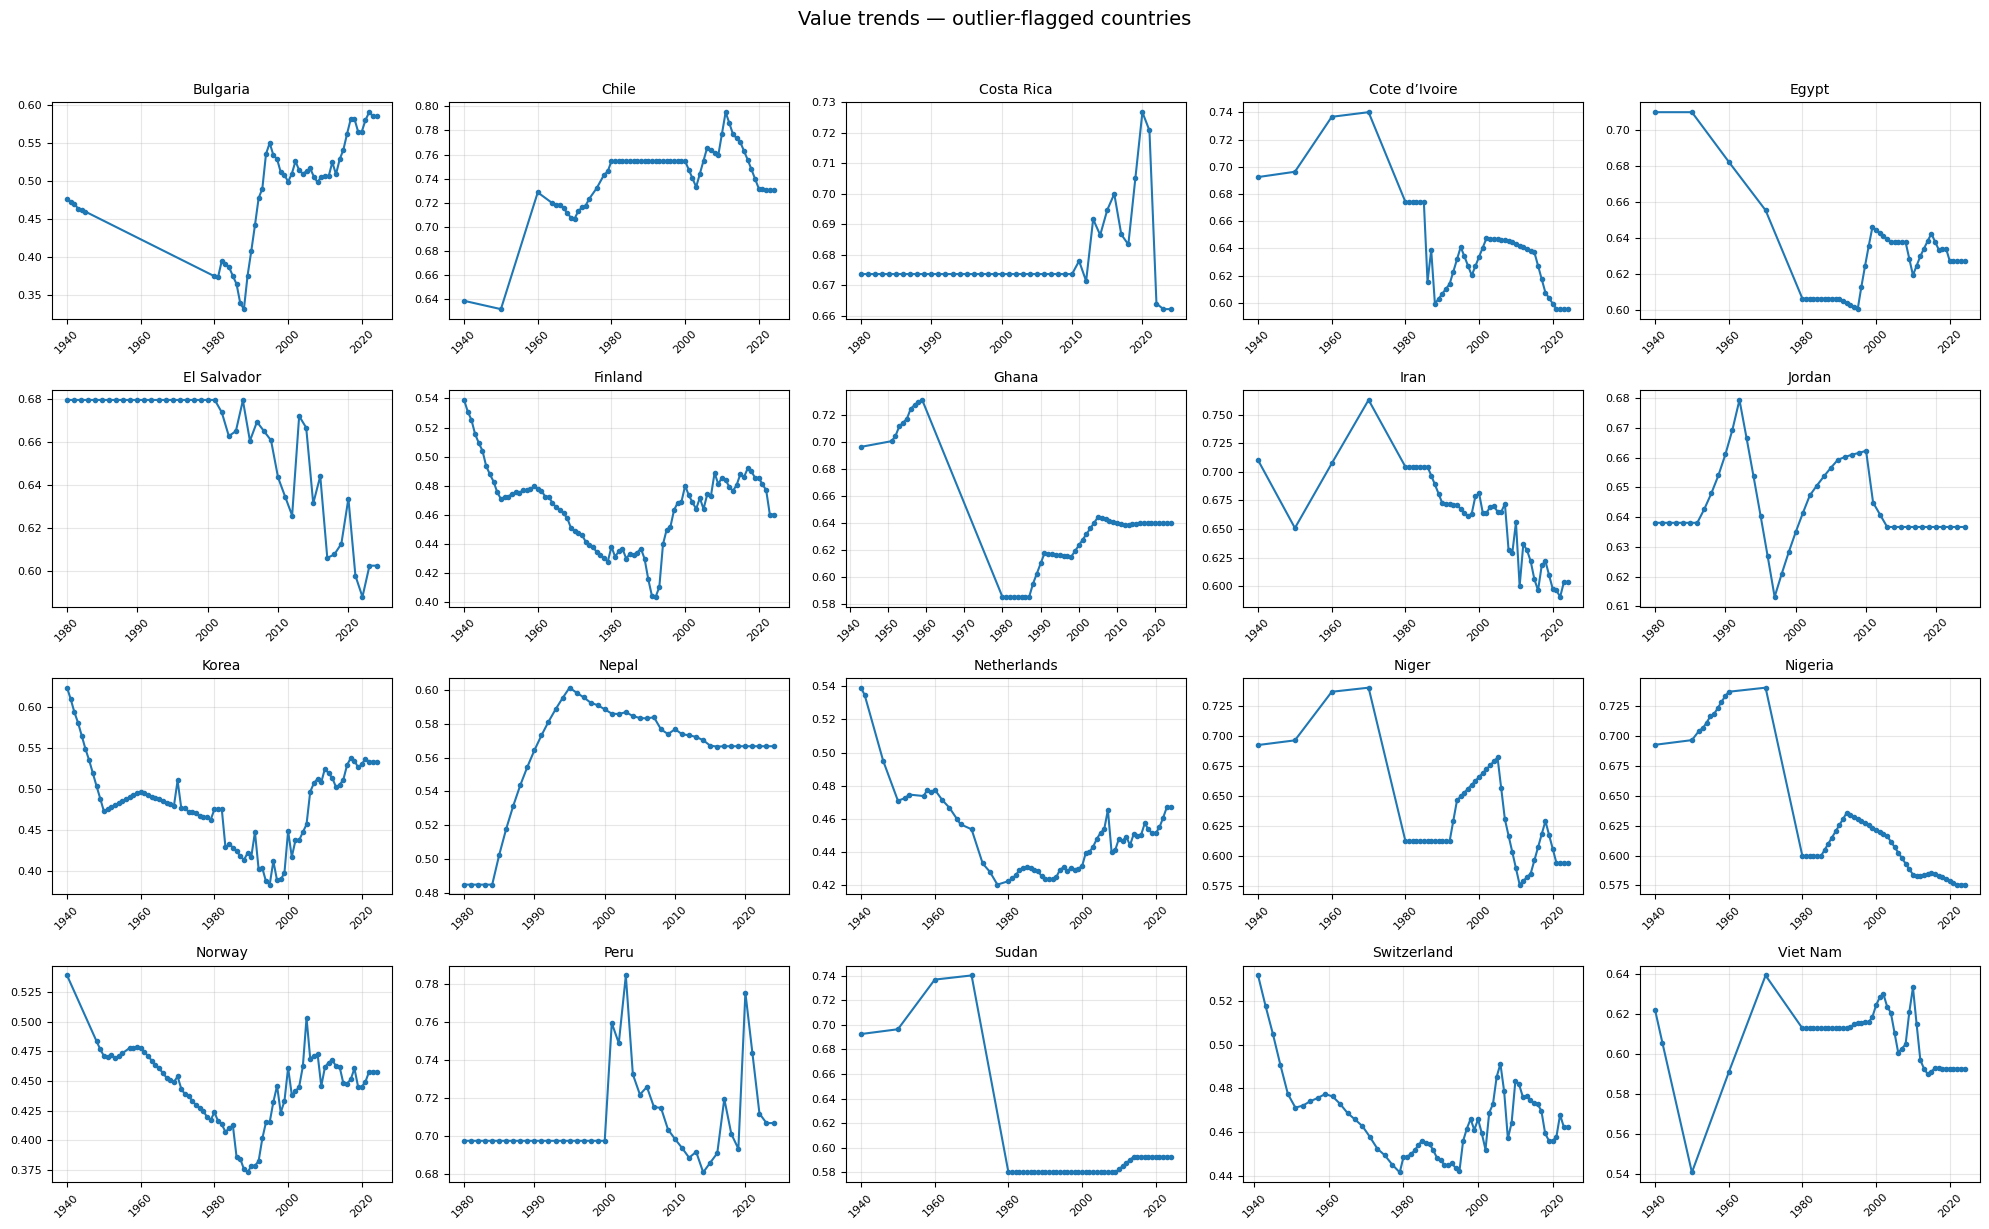

In [10]:
# Plotting only for countries, which does not comply with gini_index outliers results.
# Further investigation for inappropriate data.
def plot_all_trends(df, countries, col='Value', cols_per_row=4):
    countries = sorted(countries)
    n = len(countries)
    n_rows = int(np.ceil(n / cols_per_row))

    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 4, n_rows * 3))
    axes = axes.flatten()  # makes indexing easy regardless of grid shape

    for i, country in enumerate(countries):
        subset = df[df['Country'] == country].sort_values('Year')
        axes[i].plot(subset['Year'], subset[col], marker='o', markersize=3)
        axes[i].set_title(country, fontsize=10)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
        axes[i].tick_params(axis='y', labelsize=8)
        axes[i].grid(alpha=0.3)

    # Hide any unused subplot slots (if grid has more cells than countries)
    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{col} trends — outlier-flagged countries', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_all_trends(df_filtered, difference, col='Value', cols_per_row=5)

## Data Quality Note — Early Years (1940–1960)

Visual inspection of the merged panel shows sparse and inconsistent coverage for
**1940–1960** across most countries, producing artificial outliers in plots rather
than genuine economic signal.

**Reason:** This period predates the establishment of most national statistical
agencies and standardized household survey programs. Many countries — especially
in Sub-Saharan Africa and parts of Asia — were still under colonial administration
and lacked independent data collection infrastructure until their post-independence
years (mostly late 1950s–1960s onward). The few data points that do exist for this
window likely come from limited, non-representative sources rather than systematic
surveys, making them unreliable for cross-country comparison.

**Recommendation:** Exclude 1940–1960 from the analysis window; retain 1960 onward,
which aligns with SWIID's own stated coverage start and gives more consistent
country coverage across indicators.

In [11]:
df_filtered_final = df_filtered[df_filtered['Year'] > 1959]
df_filtered_final.head(10)

,Country,Variable,Percentile,Year,Value,Data quality,iso3,region
615,Argentina,sptinc_p80p100_999_j_AR\nPre-tax national inco...,p80p100,1960,0.6173,2.0,ARG,Latin America & Caribbean
616,Argentina,sptinc_p80p100_999_j_AR\nPre-tax national inco...,p80p100,1961,0.6193,3.0,ARG,Latin America & Caribbean
625,Argentina,sptinc_p80p100_999_j_AR\nPre-tax national inco...,p80p100,1970,0.6161,3.0,ARG,Latin America & Caribbean
635,Argentina,sptinc_p80p100_999_j_AR\nPre-tax national inco...,p80p100,1980,0.6795,1.0,ARG,Latin America & Caribbean
636,Argentina,sptinc_p80p100_999_j_AR\nPre-tax national inco...,p80p100,1981,0.6795,1.0,ARG,Latin America & Caribbean
637,Argentina,sptinc_p80p100_999_j_AR\nPre-tax national inco...,p80p100,1982,0.6795,1.0,ARG,Latin America & Caribbean
638,Argentina,sptinc_p80p100_999_j_AR\nPre-tax national inco...,p80p100,1983,0.6795,1.0,ARG,Latin America & Caribbean
639,Argentina,sptinc_p80p100_999_j_AR\nPre-tax national inco...,p80p100,1984,0.6795,1.0,ARG,Latin America & Caribbean
640,Argentina,sptinc_p80p100_999_j_AR\nPre-tax national inco...,p80p100,1985,0.6795,1.0,ARG,Latin America & Caribbean
641,Argentina,sptinc_p80p100_999_j_AR\nPre-tax national inco...,p80p100,1986,0.6795,1.0,ARG,Latin America & Caribbean
